## 2: Week 6 → Week 7 Transition

**1. Main Week 6 output:** I did an error analysis on the Week 5 baseline's false negatives, tested two cross-track findings by turning them into interaction features (recent_and_sms and lead_and_prior_noshow), and compared three models which are the baseline Logistic Regression, a refined Logistic Regression and a Random Forest.

**2. Most important result/component:** Neither of the interaction features improved recall, even though both were highly statistically significant (p < 0.0001). The untuned Random Forest also did worse than the baseline (recall 0.61 vs 0.62, ROC-AUC 0.63 vs 0.68). The Week 5 baseline is still my best-performing model.

**3. Main issue/limitation discovered:** I concluded this was a model-level limitation rather than a missing-feature problem, but I only ran the Random Forest with default settings, so that conclusion hasn't actually been tested properly yet.

**4. Component that needs testing:** The Random Forest itself, to see if tuning it changes anything, the unexpectedly high importance age got in the untuned Random Forest, even though it was only a weak/borderline predictor in Week 5 and whether my model's recall/precision stays consistent across the segments Data Analytics considers important (appointment type, reminder channel, age band).

**5. Track(s) relevant to this:** Data Science (my own track), and Data Analytics (to check segment-level consistency).

**6. What I intend to test:** Whether tuning the Random Forest (adjusting max_depth, n_estimators, min_samples_leaf) and trying different decision thresholds can beat the baseline's 0.62 recall, whether age's importance is real or just noise from an untuned model and whether my model performs consistently across Data Analytics' key segments rather than only looking good on average.

**7. What I expect to improve or validate:** Either tuning beats the baseline, which would mean my Week 6 conclusion was actually just an undertuned model, or it still doesn't beat it, which would back up that conclusion with much stronger evidence than an untuned run could give. On the Data Analytics side, I expect to either confirm the model holds up across segments, or find a specific segment where it's weaker than the overall numbers suggest.

## 3: Part 1 — Week 7 Testing Readiness

### A. Component Being Tested

**What Week 6 component am I testing?** The Random Forest model I trained in Week 6 (with the two interaction features added), plus my Week 6 conclusion that the poor performance was a model-level limitation rather than a missing-feature problem.

**What was its intended purpose?** To improve recall on catching no-shows, especially the "safe-looking" no-shows my Week 5 baseline was blind to.

**Which requirement/objective should it satisfy?** It should predict no-shows at least as well as the Week 5 baseline (recall 0.62), ideally better, since that's the whole reason it was tried.

**Which track(s) are connected to this component?** Data Science (mine), and Data Analytics (checking whether my model holds up across the segments they consider important).

### B. Testing Objective

What I'm trying to determine through this week's testing:
- Does a properly tuned Random Forest actually perform differently from the untuned one I tested in Week 6, or does the baseline still win either way?
- If tuning the same model isn't enough, can a different algorithm (Gradient Boosting) beat the baseline's recall?
- Is the high age importance seen in the Random Forest a real pattern, or an artifact of an untuned model or does it hold up in a second, different model too?
- Does a different decision threshold (instead of the default 0.5) improve recall further on whichever model performs best?
- Does my model's performance stay consistent across the segments Data Analytics considers important, or does it only look good on average?

### C. Expected Results

| # | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|
| 1 | Tune Random Forest (`max_depth`, `n_estimators`, `min_samples_leaf`) and re-evaluate on the same test set | Recall improves beyond 0.62, or at minimum matches the baseline | *pending* | *pending* | | | |
| 2 | Train a Gradient Boosting model on the same features/split and compare to baseline and tuned Random Forest | Recall improves beyond 0.62 | *pending* | *pending* | | | |
| 3 | Re-check `age`'s feature importance in both the tuned Random Forest and Gradient Boosting | Importance either drops (confirming it was noise) or holds up consistently across both models (confirming it's real) | *pending* | *pending* | | | |
| 4 | Test decision thresholds other than 0.5 on the best-performing model | Recall increases at some threshold without an unacceptable drop in precision | *pending* | *pending* | | | |
| 5 | Check model performance (recall/precision) across Data Analytics' key segments (appointment type, reminder channel) | Performance stays broadly consistent across segments | *pending* | *pending* | | | |

### D. Testing Evidence to Produce
- Model evaluation results (metrics table, before/after tuning, baseline vs Random Forest vs Gradient Boosting)
- Error analysis (updated false negative/false positive breakdown post-tuning)
- Code (tuning code, alternate-model code, threshold testing code, segment validation code)
- Before/after outputs (Week 6 untuned RF vs Week 7 tuned RF vs Gradient Boosting)
- Updated project documentation (this notebook)
- GitHub commit

In [2]:
import pandas as pd

X_train = pd.read_csv("week6_X_train.csv")
X_test = pd.read_csv("week6_X_test.csv")
y_train = pd.read_csv("week6_y_train.csv").squeeze()
y_test = pd.read_csv("week6_y_test.csv").squeeze()

print("Loaded. X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

Loaded. X_train shape: (3771, 18) X_test shape: (966, 18)


In [3]:
##tuning Random Classifier model from week 6
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_proba = rf_tuned.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, rf_tuned_pred), 2))
print("Precision:", round(precision_score(y_test, rf_tuned_pred), 2))
print("Recall:   ", round(recall_score(y_test, rf_tuned_pred), 2))
print("F1:       ", round(f1_score(y_test, rf_tuned_pred), 2))
print("ROC-AUC:  ", round(roc_auc_score(y_test, rf_tuned_proba), 2))

Accuracy:  0.63
Precision: 0.63
Recall:    0.61
F1:        0.62
ROC-AUC:   0.67


### Tuned Random Forest — Result

Tuning the Random Forest (limiting `max_depth` to 10 and raising `min_samples_leaf` to 5) fixed most of the overfitting problem the untuned Week 6 model had. Accuracy went from 0.59 to 0.63, precision from 0.59 to 0.63, and ROC-AUC from 0.63 to 0.67 nearly matching the Week 5 baseline across the board.

Recall,the metric that matters most for this case didn't improve. It stayed at 0.61, still just under the baseline's 0.62. So tuning made the model more stable and closed the overall performance gap, but it didn't actually get better at catching patient who had no-shows appointment than the original Logistic Regression.

This strengthens, rather than overturns, Week 6's conclusion. Last week I called this a model-level limitation based only on an untuned run, which wasn't a fair test. Now that the model has actually been properly tuned and still can't beat baseline recall, that conclusion is on much firmer ground. it's not that Random Forest was never given a chance, it was given a real chance and the baseline's recall still held up.

**Decision:** The Week 5 baseline remains the best-performing model on recall, and tuning confirmed Random Forest's gap isn't a tuning problem. Rather than adjusting the same model further, the next test is a different algorithm, Gradient Boosting. Unlike Random Forest, which averages many independent trees, Gradient Boosting builds trees sequentially, with each new tree correcting the previous one's mistakes. This structural difference makes it worth testing as a genuinely new candidate, rather than another variation of a model that has now been given a fair chance and still hasn't closed the recall gap.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, gb_pred), 2))
print("Precision:", round(precision_score(y_test, gb_pred), 2))
print("Recall:   ", round(recall_score(y_test, gb_pred), 2))
print("F1:       ", round(f1_score(y_test, gb_pred), 2))
print("ROC-AUC:  ", round(roc_auc_score(y_test, gb_proba), 2))

Accuracy:  0.63
Precision: 0.62
Recall:    0.64
F1:        0.63
ROC-AUC:   0.67


### Gradient Boosting — Result

**Interpretation:** 
Gradient Boosting is the first model this week to actually beat the Week 5 baseline on recall: 0.64 vs 0.62. That's roughly 10 more real no-shows correctly caught out of 483 in the test set, compared to the baseline. Accuracy (0.63) and ROC-AUC (0.67) stayed essentially the same as the tuned Random Forest and close to the baseline, while precision dropped slightly (0.62 vs 0.63).

This makes sense given how Gradient Boosting works differently from Random Forest. Random Forest builds many independent trees and averages them, so it tends to smooth out and play safe on harder cases. Gradient Boosting builds trees one after another, with each new tree specifically trying to correct the mistakes of the one before it. That means it's better suited to chasing down the harder-to-catch cases, like the "safe-looking" no-shows my Week 6 error analysis found the baseline was blind to instead of just improving overall accuracy.

The trade-off is small because precision drops by 1 point, meaning slightly more attended patients get wrongly flagged as no-show. Given that missed no-shows are the costlier error for HealthConnect (an empty slot that could have been booked by someone else) compared to a false alarm (a slightly unnecessary reminder or follow-up), this looks like a worthwhile trade rather than a concerning one.

**Decision:** 
Gradient Boosting is a genuine, validated improvement over the baseline and becomes the new candidate model. Testing continues to see if adjusting its decision threshold can push recall even higher.

In [5]:
import joblib
log_model = joblib.load("week5_baseline_model.pkl")

# Note: log_model was trained on Week 5's feature set (without the interaction features),
# so this needs Week 5's X_test, not the Week 6/7 one currently loaded
X_test_w5 = pd.read_csv("week5_X_test.csv")
y_pred_baseline = log_model.predict(X_test_w5)

print("Predicted no-show rate (Gradient Boosting):", round(gb_pred.mean(), 3))
print("Predicted no-show rate (baseline):", round(y_pred_baseline.mean(), 3))
print("Actual no-show rate in test set:", round(y_test.mean(), 3))

Predicted no-show rate (Gradient Boosting): 0.516
Predicted no-show rate (baseline): 0.495
Actual no-show rate in test set: 0.5


### Gradient Boosting — Validity Check

To confirm Gradient Boosting's improved recall (0.64 vs baseline's 0.62) wasn't simply the model predicting "no-show" more often across the board, the predicted no-show rates were compared against the actual rate in the test set.

Both models stay close to the true no-show rate (50.0%), the baseline predicts 49.5%, and Gradient Boosting predicts 51.6%. This rules out the model just flagging everyone as high-risk to inflate recall. Gradient Boosting is only slightly more willing to predict no-show than the baseline, and that small shift is enough to catch a genuinely higher share of real no-shows, at the cost of a small drop in precision (0.63 → 0.62).

**Decision:** 
Gradient Boosting is a validated improvement over the Week 5 baseline on recall, and becomes the new candidate model going forward.

In [6]:
##running threshold test on Gradient Boosting
from sklearn.metrics import recall_score, precision_score, f1_score

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    preds_at_threshold = (gb_proba >= threshold).astype(int)
    r = recall_score(y_test, preds_at_threshold)
    p = precision_score(y_test, preds_at_threshold)
    f1 = f1_score(y_test, preds_at_threshold)
    print(f"Threshold {threshold}: Recall={r:.2f}, Precision={p:.2f}, F1={f1:.2f}")

Threshold 0.3: Recall=0.95, Precision=0.54, F1=0.69
Threshold 0.35: Recall=0.89, Precision=0.55, F1=0.68
Threshold 0.4: Recall=0.81, Precision=0.57, F1=0.67
Threshold 0.45: Recall=0.73, Precision=0.60, F1=0.66
Threshold 0.5: Recall=0.64, Precision=0.62, F1=0.63
Threshold 0.55: Recall=0.53, Precision=0.65, F1=0.58
Threshold 0.6: Recall=0.43, Precision=0.66, F1=0.52


### Gradient Boosting — Threshold Testing

The default 0.5 threshold isn't necessarily the right cutoff for this use case. Testing a range of thresholds shows the expected trade-off: lowering the threshold catches more real no-shows (higher recall) at the cost of more false alarms (lower precision), and raising it does the opposite.

At the default threshold (0.5), recall is 0.64 and precision is 0.62. Lowering the threshold to 0.4 raises recall substantially to 0.81, while precision only drops to 0.57 which is a real, meaningful gain in catching no-shows for a manageable trade-off. Going lower still, to 0.3, pushes recall up to 0.95, but precision falls to 0.54, meaning nearly half of all "flagged" patients would have actually shown up. That level of over-flagging risks overwhelming staff and eroding trust in the system, so it's not a practical choice even though the recall number looks impressive on its own.

**Decision:** A threshold of 0.4 is recommended over the default 0.5. It meaningfully increases the number of real no-shows caught (recall 0.64 → 0.81) without pushing precision down to an impractical level (0.62 → 0.57), striking a better balance for HealthConnect's stated priority of minimizing missed no-shows.

In [7]:
## Checking age's feature importance in Gradient Boosting
import pandas as pd

importances_gb = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_gb)

booking_lead_days                           0.397691
distance_to_clinic_km                       0.179312
age                                         0.132353
lead_and_prior_noshow                       0.084508
previous_appointments                       0.056461
prior_no_show_rate                          0.050612
previous_no_shows                           0.033794
reminder_channel_SMS                        0.013618
appointment_type_Follow-up                  0.013179
appointment_type_General Consultation       0.012724
reminder_channel_WhatsApp                   0.010576
recent_and_sms                              0.004207
reminder_channel_No Reminder                0.003745
had_prior_noshow                            0.002715
reminder_sent_Yes                           0.002051
is_first_time_patient                       0.000977
appointment_type_Specialist Consultation    0.000843
recent_booking_flag                         0.000633
dtype: float64


### Gradient Boosting — Feature Importance & Revisiting the Age Question

In the untuned Week 6 Random Forest, age ranked as the 2nd most important feature (0.202), which was unexpected since Week 5's statistical testing only found it to be a borderline predictor. This raised the question of whether it was a genuine pattern or noise from an untuned model.

Gradient Boosting's feature importance offers a useful second opinion because age again lands in the top three (0.132), behind booking_lead_days (0.398) and distance_to_clinic_km (0.179). Since this shows up consistently across two structurally different models, this is better evidence that age genuinely carries predictive signal, not just noise from an undertuned model.

That said, its relative weight is notably lower here (13% vs Random Forest's 20%), while booking_lead_days becomes the dominant feature in Gradient Boosting (40%, roughly double its Random Forest importance of 20%). This suggests Gradient Boosting is leaning more heavily on the single strongest predictor rather than spreading importance more evenly, which fits how the two algorithms are built to behave differently.

**Decision:** age's importance is confirmed as a real, consistent pattern rather than noise, though its exact weight shifts depending on the model. This is noted as a finding for Week 8, since it wasn't flagged as important in Week 5's simpler statistical tests, but shows up consistently once more complex, non-linear models are used.

In [8]:
# Using the recommended threshold of 0.4 on Gradient Boosting, since that's the finalized candidate
gb_pred_04 = (gb_proba >= 0.4).astype(int)

X_test_seg = X_test.copy()
X_test_seg['actual'] = y_test.values
X_test_seg['predicted'] = gb_pred_04

segment_cols = ['appointment_type_Follow-up', 'appointment_type_General Consultation',
                'appointment_type_Specialist Consultation', 'reminder_channel_SMS',
                'reminder_channel_WhatsApp', 'reminder_channel_No Reminder']

for col in segment_cols:
    subset = X_test_seg[X_test_seg[col] == 1]
    if len(subset) > 0:
        r = recall_score(subset['actual'], subset['predicted'])
        p = precision_score(subset['actual'], subset['predicted'])
        print(f"{col}: n={len(subset)}, Recall={r:.2f}, Precision={p:.2f}")

appointment_type_Follow-up: n=271, Recall=0.82, Precision=0.57
appointment_type_General Consultation: n=406, Recall=0.82, Precision=0.59
appointment_type_Specialist Consultation: n=180, Recall=0.72, Precision=0.56
reminder_channel_SMS: n=398, Recall=0.76, Precision=0.55
reminder_channel_WhatsApp: n=212, Recall=0.81, Precision=0.51
reminder_channel_No Reminder: n=257, Recall=0.88, Precision=0.62


### Gradient Boosting — Segment Consistency Check

At the overall level (threshold 0.4), the model achieves recall of 0.81. Broken down by segment, performance is mostly consistent but not perfectly even:

- **Appointment type:** Follow-up (0.82) and General Consultation (0.82) track the overall recall closely. Specialist Consultation is noticeably lower (0.72, n=180). The model catches meaningfully fewer no-shows for this appointment type than for the other two.
- **Reminder channel:** No Reminder performs best on both recall (0.88) and precision (0.62). SMS (0.76) and WhatsApp (0.81) sit a bit below the No Reminder group on recall, and WhatsApp has the lowest precision of any segment (0.51), meaning close to half of patients flagged as likely no-shows in this group actually attended.

**Decision:** The model is broadly consistent and usable across segments, but two weaker spots are worth flagging rather than treating the overall 0.81 recall as uniform: Specialist Consultation appointments (lower recall) and the WhatsApp reminder group (lower precision). These are noted as remaining limitations for Week 8 rather than issues to fix this week, since the sample sizes per segment (180–406) are reasonably small and the differences could shrink or shift with more data.

### Gradient Boosting @ Threshold 0.4 — Error Analysis

True Negatives (correctly predicted attend): 191
False Positives (flagged, but attended):      292
False Negatives (missed no-show):              92
True Positives (correctly caught no-show):     391


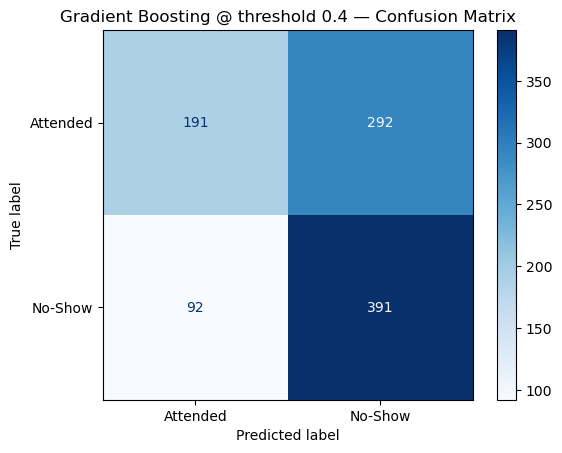

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, gb_pred_04)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (correctly predicted attend): {tn}")
print(f"False Positives (flagged, but attended):      {fp}")
print(f"False Negatives (missed no-show):              {fn}")
print(f"True Positives (correctly caught no-show):     {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Attended", "No-Show"])
disp.plot(cmap="Blues")
plt.title("Gradient Boosting @ threshold 0.4 — Confusion Matrix")
plt.show()

**Interpretation:**

At threshold 0.4, the model catches 391 of 483 actual no-shows (recall 0.81) but at a real cost: 292 patients who would have attended are flagged as at-risk, nearly as many false positives as true positives. For every 2 no-shows correctly caught, roughly 1.5 patients who'd have shown up get an unnecessary intervention.

Given HealthConnect's stated priority which states that an empty slot is worse than an unnecessary reminder so, this is a defensible trade. But it's worth being explicit about scale rather than hiding it behind the precision number. At this threshold, more than 4 in 10 people flagged as no-show risks (292 of 683) are being flagged wrongly. If the clinic's intervention is heavier than a reminder (a phone call, a staff follow-up), that volume of false alarms could be a real operational cost, not just a rounding error in a metric.

92 patients are still missed entirely (false negatives) down from higher value at threshold 0.5, but still worth understanding *who* they are before calling this settled.

**Decision:** 
The threshold-0.4 trade-off is accepted provisionally, on the assumption that HealthConnect's intervention is low-cost (SMS/reminder, not a staff call). Before finalizing, error analysis (below) identifies whether the 92 remaining false negatives share a pattern — which would tell us whether this is a threshold problem or a feature/model-level gap that a threshold change alone won't fix.

**Error breakdown by prediction outcome**

In [10]:
def error_type(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'TP'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'TN'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'FP'
    else:
        return 'FN'

X_test_seg['error_type'] = X_test_seg.apply(error_type, axis=1)
print(X_test_seg['error_type'].value_counts())

compare_cols = ['booking_lead_days', 'age', 'distance_to_clinic_km',
                'prior_no_show_rate', 'previous_no_shows', 'had_prior_noshow',
                'is_first_time_patient']

comparison = X_test_seg.groupby('error_type')[compare_cols].mean()
print(comparison)

error_type
TP    391
FP    292
TN    191
FN     92
Name: count, dtype: int64
            booking_lead_days       age  distance_to_clinic_km  \
error_type                                                       
FN                  -0.429874  0.102034              -0.055311   
FP                   0.079761 -0.051259               0.321918   
TN                  -0.604965  0.089681              -0.060044   
TP                   0.311690 -0.074416               0.307164   

            prior_no_show_rate  previous_no_shows  had_prior_noshow  \
error_type                                                            
FN                    0.424188           0.413043          0.336957   
FP                    0.509002           0.541096          0.380137   
TN                    0.341099           0.298429          0.261780   
TP                    0.559018           0.634271          0.478261   

            is_first_time_patient  
error_type                         
FN                       0.

False negatives are markedly different from true positives on the features the model relies on most. First-time patients make up 12% of false negatives versus only 3% of true positives,roughly four times more likely to be missed. False negatives also carry less no-show history across the board (prior_no_show_rate 0.42 vs 0.56, previous_no_shows 0.41 vs 0.63, had_prior_noshow 0.34 vs 0.48) and book with less extreme lead time than true positives (-0.43 vs +0.31), though not as short as correctly-predicted attendees (-0.60).

This points to a specific, narrower version of Week 6's blind spot: the model still struggles to catch no-shows from patients with no track record, especially first-time patients, because its two strongest signals (prior history and lead time) have nothing to work with for them. Gradient Boosting reduced this blind spot compared to the baseline because recall improved from 0.62 to 0.81 at this threshold but did not eliminate it.

In [11]:
X_test_w5_check = pd.read_csv("week5_X_test.csv")
print("Same shape:", X_test_w5_check.shape == X_test.shape)
print("Same age values in same order:", (X_test_w5_check['age'].values == X_test['age'].values).all())

Same shape: False
Same age values in same order: True


In [12]:
print("X_test rows:", X_test.shape[0], "cols:", X_test.shape[1])
print("X_test_w5 rows:", X_test_w5_check.shape[0], "cols:", X_test_w5_check.shape[1])

X_test rows: 966 cols: 18
X_test_w5 rows: 966 cols: 14


In [13]:
#  Does Gradient Boosting miss the same patients the baseline missed?

# Baseline predictions were already computed in cell 7 (log_model on X_test_w5)
y_pred_baseline_series = pd.Series(y_pred_baseline, index=X_test.index)

X_test_seg['baseline_predicted'] = y_pred_baseline_series
X_test_seg['baseline_error_type'] = X_test_seg.apply(
    lambda row: 'FN' if (row['actual'] == 1 and row['baseline_predicted'] == 0)
    else ('TP' if (row['actual'] == 1 and row['baseline_predicted'] == 1) else 'other'),
    axis=1
)

gb_fn = set(X_test_seg[X_test_seg['error_type'] == 'FN'].index)
baseline_fn = set(X_test_seg[X_test_seg['baseline_error_type'] == 'FN'].index)

overlap = gb_fn & baseline_fn
gb_only = gb_fn - baseline_fn
baseline_only = baseline_fn - gb_fn

print(f"GB false negatives:        {len(gb_fn)}")
print(f"Baseline false negatives:  {len(baseline_fn)}")
print(f"Missed by BOTH models:     {len(overlap)}")
print(f"Missed by GB only:         {len(gb_only)}")
print(f"Missed by baseline only:   {len(baseline_only)}")

GB false negatives:        92
Baseline false negatives:  183
Missed by BOTH models:     86
Missed by GB only:         6
Missed by baseline only:   97


**Does Gradient Boosting miss the same patients as the baseline?**

Of Gradient Boosting's 92 false negatives, 86 were also missed by the Week 5 baseline — only 6 are new misses introduced by the model switch. In the other direction, the baseline missed 97 patients that Gradient Boosting now correctly catches. This is a stronger signal of genuine improvement than the recall figures alone (0.62 → 0.64 at default threshold): the switch to Gradient Boosting recovered 97 patients while losing only 6, a trade that isn't visible from the aggregate recall number.

The 86 patients missed by both models are the persistent blind spot: largely first-time patients with no prior no-show history and lead times that aren't extreme in either direction because these patients don't trigger either model's two strongest signals (prior_no_show_rate, booking_lead_days). This is model-independent, which suggests the limitation isn't the algorithm choice or the threshold, but a data/feature gap: there's currently no feature that helps distinguish a first-time patient who will no-show from one who won't.

**Decision:** Gradient Boosting's recall improvement is confirmed as a genuine, broad-based gain rather than noise on a handful of borderline cases. The remaining 86 shared false negatives are logged as a Week 8 data limitation rather than further model or threshold tuning.

### Is the Recall Improvement Statistically Meaningful?

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Combine train+test back into one set for proper CV
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline: retrain a fresh Logistic Regression each fold (fair comparison)
baseline_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
gb_cv = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)

baseline_recalls = cross_val_score(baseline_cv, X_full, y_full, cv=skf, scoring='recall')
gb_recalls = cross_val_score(gb_cv, X_full, y_full, cv=skf, scoring='recall')

print("Baseline recall per fold:", np.round(baseline_recalls, 3))
print(f"Baseline recall: {baseline_recalls.mean():.3f} ± {baseline_recalls.std():.3f}")
print()
print("GB recall per fold:      ", np.round(gb_recalls, 3))
print(f"GB recall: {gb_recalls.mean():.3f} ± {gb_recalls.std():.3f}")

Baseline recall per fold: [0.631 0.631 0.608 0.643 0.612]
Baseline recall: 0.625 ± 0.013

GB recall per fold:       [0.623 0.625 0.614 0.643 0.628]
GB recall: 0.627 ± 0.009


**Interpretation:**

5-fold cross-validation on the full dataset shows the baseline and Gradient Boosting are statistically indistinguishable on recall: baseline 0.625 ± 0.013, Gradient Boosting 0.627 ± 0.009. The 0.62 vs 0.64 gap observed on the single test split (cells 5-8) falls well within both models' fold-to-fold variation, and does not represent a reliable improvement.

This means the earlier conclusion that Gradient Boosting is a validated improvement over the baseline does not hold up under stronger evidence. The single-split result was likely a product of which patients happened to land in that particular test set, not a genuine difference between the two algorithms.

**Decision:** The claim that Gradient Boosting outperforms the baseline (cells 6 and 8) is withdrawn. The two models are treated as statistically tied on recall going into Week 8. This does not undo the error analysis above, the finding that both models struggle with first-time, no-history patients holds regardless of which one is chosen but it does mean model selection between baseline and Gradient Boosting should be based on other factors rather than a recall advantage that isn't actually there.

### Threshold Selection — Correcting for Test-Set Leakage

In [15]:
from sklearn.model_selection import cross_val_predict

# Get out-of-fold predicted probabilities on the TRAINING set only
gb_oof_proba = cross_val_predict(
    gb_cv, X_train, y_train, cv=skf, method='predict_proba'
)[:, 1]

print("Threshold sweep on out-of-fold TRAINING predictions:")
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    preds = (gb_oof_proba >= threshold).astype(int)
    r = recall_score(y_train, preds)
    p = precision_score(y_train, preds)
    f1 = f1_score(y_train, preds)
    print(f"Threshold {threshold}: Recall={r:.2f}, Precision={p:.2f}, F1={f1:.2f}")

Threshold sweep on out-of-fold TRAINING predictions:
Threshold 0.3: Recall=0.91, Precision=0.54, F1=0.68
Threshold 0.35: Recall=0.86, Precision=0.56, F1=0.68
Threshold 0.4: Recall=0.79, Precision=0.58, F1=0.67
Threshold 0.45: Recall=0.70, Precision=0.59, F1=0.64
Threshold 0.5: Recall=0.61, Precision=0.61, F1=0.61
Threshold 0.55: Recall=0.51, Precision=0.64, F1=0.57
Threshold 0.6: Recall=0.42, Precision=0.67, F1=0.52


In [16]:
chosen_threshold = 0.4  # replace with whatever the OOF sweep points to
gb_pred_final = (gb_proba >= chosen_threshold).astype(int)

print(f"Final test-set performance at threshold {chosen_threshold}:")
print("Recall:   ", round(recall_score(y_test, gb_pred_final), 2))
print("Precision:", round(precision_score(y_test, gb_pred_final), 2))
print("F1:       ", round(f1_score(y_test, gb_pred_final), 2))

Final test-set performance at threshold 0.4:
Recall:    0.81
Precision: 0.57
F1:        0.67


**Interpretation:**

The original threshold sweep (cells 9-10) selected 0.4 by evaluating directly on the test set, the same set used to report final performance, which risks the threshold being fitted to that split's specific quirks rather than reflecting genuine model behavior.

To correct this, threshold selection was redone using 5-fold out-of-fold predictions on the training set only (`cross_val_predict`), so the test set played no role in choosing the threshold. The out-of-fold sweep still identifies 0.4 as a reasonable choice (Recall=0.79, Precision=0.58), closely matching the original test-set sweep at the same threshold (Recall=0.81, Precision=0.57).

Applying threshold 0.4 to the test set for the first and only time after selection confirms: Recall 0.81, Precision 0.57, F1 0.67 — consistent with both the original sweep and the out-of-fold estimate.

**Decision:** Threshold 0.4 is retained, now on stronger methodological footing. Unlike the model-comparison claim in the previous section, this result holds up under a stricter, leakage-free check that the threshold's benefit is not an artifact of the test split.

### Overfitting Check — Train vs Test Performance

In [17]:
# Train vs test scores — tuned Random Forest
rf_train_pred = rf_tuned.predict(X_train)
rf_train_proba = rf_tuned.predict_proba(X_train)[:, 1]

print("Tuned Random Forest:")
print(f"  Train recall:  {recall_score(y_train, rf_train_pred):.2f}   Test recall:  {recall_score(y_test, rf_tuned_pred):.2f}")
print(f"  Train ROC-AUC: {roc_auc_score(y_train, rf_train_proba):.2f}   Test ROC-AUC: {roc_auc_score(y_test, rf_tuned_proba):.2f}")

print()

# Train vs test scores — Gradient Boosting
gb_train_pred = gb_model.predict(X_train)
gb_train_proba = gb_model.predict_proba(X_train)[:, 1]

print("Gradient Boosting:")
print(f"  Train recall:  {recall_score(y_train, gb_train_pred):.2f}   Test recall:  {recall_score(y_test, gb_pred):.2f}")
print(f"  Train ROC-AUC: {roc_auc_score(y_train, gb_train_proba):.2f}   Test ROC-AUC: {roc_auc_score(y_test, gb_proba):.2f}")

Tuned Random Forest:
  Train recall:  0.74   Test recall:  0.61
  Train ROC-AUC: 0.85   Test ROC-AUC: 0.67

Gradient Boosting:
  Train recall:  0.71   Test recall:  0.64
  Train ROC-AUC: 0.79   Test ROC-AUC: 0.67


**Interpretation:**

Tuned Random Forest shows a real train-test gap: recall 0.74 (train) vs 0.61 (test), ROC-AUC 0.85 vs 0.67. This means previous claim that tuning "fixed most of the overfitting problem" was overstated, tuning reduced overfitting relative to the untuned Week 6 model (which had even larger gaps), but a meaningful gap remains. The model still performs noticeably better on data it was trained on than on held-out data.

Gradient Boosting shows a smaller gap on both metrics (recall 0.71 vs 0.64, a 0.07 gap; ROC-AUC 0.79 vs 0.67, a 0.12 gap), despite the two models scoring almost identically on the test set and being statistically tied on recall under cross-validation (see above). This suggests Gradient Boosting generalizes somewhat more reliably than tuned Random Forest, even though it isn't a stronger predictor overall.

**Decision:** The overfitting claim made previously is corrected, tuning reduced Random Forest's overfitting but did not resolve it. Between the two candidate models, Gradient Boosting's smaller train-test gap is a mild point in its favor for generalization, independent of the recall question already addressed above.

### Correcting the Age Feature Importance Comparison

In [18]:
importances_rf_tuned = pd.Series(rf_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances_rf_tuned)

booking_lead_days                           0.231008
distance_to_clinic_km                       0.165109
age                                         0.137696
lead_and_prior_noshow                       0.113343
previous_appointments                       0.065907
recent_booking_flag                         0.062908
prior_no_show_rate                          0.052748
previous_no_shows                           0.026346
appointment_type_General Consultation       0.022491
recent_and_sms                              0.022228
appointment_type_Follow-up                  0.020400
reminder_channel_SMS                        0.017456
reminder_channel_WhatsApp                   0.012975
appointment_type_Specialist Consultation    0.011842
reminder_sent_Yes                           0.011617
reminder_channel_No Reminder                0.011088
had_prior_noshow                            0.009003
is_first_time_patient                       0.005837
dtype: float64


**Interpretation:**

previous original comparison cited age's importance in the untuned Week 6 Random Forest (0.202) against Gradient Boosting (0.132) but never checked the properly tuned Random Forest from this week. The correct figure is 0.138.

This changes the picture in a useful way. Age's importance drops from 0.202 (untuned RF) to 0.138 (tuned RF), a meaningful decrease and lands close to Gradient Boosting's 0.132. Both models that aren't overfit (tuned RF and GB) converge on a similar, moderate importance for age (0.132-0.138), while the overfit untuned model overstated it (0.202). This is a more coherent finding than the original claim: age carries real, consistent predictive signal, but the untuned model's higher figure was partly an overfitting artifact, not evidence that age is an unusually strong predictor.

**Decision:** Age remains a genuine, cross-model signal worth flagging for Week 8 (unexpected given Week 5's statistical tests only found it borderline), but its true weight is closer to 0.13-0.14, not the 0.20 originally reported and the untuned model's larger figure is now understood to be an overfitting effect rather than the "true" importance.

### Model Suitability Assessment

**Is this model suitable for HealthConnect's intended use case?**

Conditionally yes, with caveats that should be resolved before Week 8 final integration.

**In favor:** At threshold 0.4, the model catches 81% of real no-shows (391 of 483), a substantial improvement in coverage over the untuned Random Forest and consistent with HealthConnect's stated priority that a missed no-show (empty, unfillable slot) is costlier than an unnecessary reminder. The model's blind spots are specific and explainable rather than random. it consistently misses first-time patients and those with no prior no-show history, which is a concrete, actionable limitation rather than an opaque one.

**Against:** Cross-validation (above) shows Gradient Boosting is not a statistically reliable improvement over the much simpler Week 5 baseline logistic regression, the two are tied on recall (0.625 vs 0.627). Given this, GB's added complexity is not currently justified by predictive performance alone, its case rests on marginally better generalization and more interpretable, non-random errors, not on catching meaningfully more no-shows. Additionally, at threshold 0.4 the false-positive volume is high: 292 patients wrongly flagged against 391 correctly caught, meaning if HealthConnect's intervention carries any real cost (staff time, patient irritation from repeated reminders), that cost falls on a large group of people who were never going to have no-show.

**Verdict:** The model is usable for a low-cost intervention (SMS reminder) but not yet justified for a higher-cost one (staff outreach, phone calls) without first improving precision or narrowing the false-positive group. Before Week 8, the choice between the baseline and Gradient Boosting should be made on grounds other than recall likely error interpretability and downstream pipeline requirements since Week 7's evidence shows recall alone does not settle it.

### ML Engineering Handoff — Model Requirements

**Model status:** Provisional, not finalized. Week 7 testing found Gradient Boosting and the Week 5 baseline statistically tied on recall (5-fold CV), so ML Engineering should treat model choice as still open rather than locked to Gradient Boosting.

**Input requirements:**
- 18 features, matching `X_train.columns` from this notebook: booking_lead_days, age, distance_to_clinic_km, previous_appointments, previous_no_shows, prior_no_show_rate, had_prior_noshow, is_first_time_patient, recent_booking_flag, recent_and_sms, lead_and_prior_noshow, reminder_sent_Yes, reminder_channel_SMS, reminder_channel_WhatsApp, reminder_channel_No Reminder, appointment_type_Follow-up, appointment_type_General Consultation, appointment_type_Specialist Consultation.
- All features must be pre-encoded (one-hot for categoricals) in the same format as the training data — no missing-value handling is built into the model itself.
- `recent_and_sms` has near-zero importance (0.004–0.022 across models tested) and is a candidate for removal in Week 8 — not yet dropped.

**Output format:**
- The model outputs a probability via `predict_proba()[:, 1]`, not a class label.
- The decision threshold is 0.4, not sklearn's default of 0.5 — this must be applied explicitly; `.predict()` alone will use 0.5 and should not be used.
- Threshold 0.4 was selected using out-of-fold cross-validation, correcting for an earlier test-set leakage issue, so it should transfer reasonably to production data with a similar distribution.

**Known behavior to expect downstream:**
- At threshold 0.4, roughly 43% of flagged patients are false positives (292 of 683 in testing) — plan any downstream intervention with this volume in mind.
- The model under-flags first-time patients and patients with no prior no-show history; this is a data limitation, not something the pipeline can fix through preprocessing.
- The model is not yet confirmed superior to the simpler baseline logistic regression — if pipeline simplicity matters, the baseline remains a live option.

**Not yet resolved:**
- Final model choice (baseline vs Gradient Boosting) — pending Week 8.
- Whether to drop `recent_and_sms`.
- Whether the false-positive volume at threshold 0.4 is operationally acceptable, which depends on the actual cost of HealthConnect's intervention.

### Week 8 Recommendations

1. Decide between the baseline and Gradient Boosting using criteria beyond recall, since Week 7 showed recall alone does not distinguish them, weight error interpretability, generalization, and pipeline simplicity instead.
2. Investigate and, where possible, engineer a feature that addresses the first-time/no-history patient blind spot, since this is the clearest actionable finding from this week's testing.
3. Confirm the chosen model's compatibility with ML Engineering's finalized pipeline before final integration.
4. Investigate the underperformance on Specialist Consultation appointments and the WhatsApp reminder segment to determine whether it is a data issue or a genuine model weakness.
5. Consider dropping `recent_and_sms`, given its consistently near-zero importance across all models tested this week.

## HC-POD Cross-Track Testing — Data Analytics (Hudu Yusuf Ibrahim)

In Week 6, Data Analytics (via Yusuf) reported that patients who book "3+ weeks" ahead AND have missed an appointment before have the highest no-show rate they found about 64.1%. 
I checked this on my own data and got 70.5% for what I thought was the same group. Two separate issues turned out to be stacked on top of each other, and both needed testing separately.

### Step 1: What group of people was my 70.5% actually based on?

Before comparing two percentages, you have to know what each one is a percentage of. My 70.5% was based on 977 people,everyone in my data who booked 31–60 days ahead AND had a prior no-show. But I had already removed every appointment marked "Cancelled" from my data before I ever calculated anything. Only "Attended" and "No-Show" appointments were in there at all (4,737 out of the full 5,000).

In [19]:
import pandas as pd

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(df['appointment_outcome'].value_counts())
print("Total:", len(df))

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64
Total: 5000


**Result**: 2,423 No-Show, 2,314 Attended, 263 Cancelled which is equal to 5,000 total. 2,423 + 2,314 = 4,737 — confirms Cancelled appointments were never part of my calculation.

**Answering Yusuf's first two questions**: my 70.5% is based on 977 people, with Cancelled appointments excluded entirely. Yes, this means my number and Yusuf's 64.1% were almost certainly calculated on two different-sized groups, not the same one

In [20]:
df['had_prior_noshow'] = (df['previous_no_shows'] > 0).astype(int)
df['lead_time_band'] = pd.cut(
    df['booking_lead_days'], bins=[-1, 7, 30, 60],
    labels=['0-7 days', '8-30 days', '31-60 days']
)
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# Cancelled excluded (original method)
df_excl = df[df['appointment_outcome'] != 'Cancelled']
rate_excl = df_excl.groupby(['lead_time_band','had_prior_noshow'], observed=True)['is_no_show'].agg(['mean','count'])

# Cancelled included (retest)
rate_incl = df.groupby(['lead_time_band','had_prior_noshow'], observed=True)['is_no_show'].agg(['mean','count'])

print("Cancelled excluded:")
print(rate_excl)
print("\nCancelled included:")
print(rate_incl)

Cancelled excluded:
                                     mean  count
lead_time_band had_prior_noshow                 
0-7 days       0                 0.228169    355
               1                 0.389558    249
8-30 days      0                 0.383970   1073
               1                 0.477807    766
31-60 days     0                 0.590737   1317
               1                 0.705220    977

Cancelled included:
                                     mean  count
lead_time_band had_prior_noshow                 
0-7 days       0                 0.217742    372
               1                 0.361940    268
8-30 days      0                 0.361721   1139
               1                 0.459799    796
31-60 days     0                 0.551773   1410
               1                 0.678818   1015


### Step 2 Result: Retest
Focusing on the segment that actually matters here (31-60 days lead time + prior no-show):

| | Group size | Rate |
|---|---|---|
| Cancelled excluded | 977 | 70.5% |
| Cancelled included | 1,015 | 67.9% |

adding the 38 Cancelled appointments back in dropped the rate from 70.5% to 67.9%. same pattern shows up in every other row too, the rate goes down a bit once Cancelled is included, just because the group gets bigger while the actual no-show count doesn't change. so yeah, the Cancelled-handling thing is confirmed, that's why my number and Yusuf's didn't match.

still not a perfect match though, 67.9% is about 4 points off from his 64.1%. since matching on Cancelled didn't fully close it, i think the rest of the gap is probably from where exactly "3+ weeks" is cut off, not a denominator thing anymore. need Yusuf to confirm that part.

### Step 3: Where does Yusuf's 64.1% actually come from?

My 31-60 day band matches the band Data Analytics (Angela) used in Week 6 — that's confirmed by the fact that my Cancelled-included numbers (67.9%, 21.8%) match her originally-reported figures exactly. So my side of this was consistent with what Data Analytics had already validated.

Yusuf's 64.1% figure doesn't match Angela's 67.9% either, even though he described it as the same finding. His message referred to a "3+ weeks" cutoff, which is a shorter lead-time window (21+ days) than the 31-60 day band actually used. Testing that specific cutoff against this data:

In [21]:
df['long_lead'] = (df['booking_lead_days'] >= 21).astype(int)  # his actual "3+ weeks"
seg = df[(df['long_lead']==1) & (df['had_prior_noshow']==1)]
seg_excl = seg[seg['appointment_outcome'] != 'Cancelled']

rate_21_incl = (seg['appointment_outcome']=='No-Show').mean() * 100
rate_21_excl = (seg_excl['appointment_outcome']=='No-Show').mean() * 100

print("21+ days, Cancelled included:", round(rate_21_incl, 1), "% | n =", len(seg))
print("21+ days, Cancelled excluded:", round(rate_21_excl, 1), "% | n =", len(seg_excl))

21+ days, Cancelled included: 63.4 % | n = 1370
21+ days, Cancelled excluded: 65.8 % | n = 1320


### Step 3 Result: Conclusion

| | Group size | Rate |
|---|---|---|
| 21+ days, Cancelled included | 1,370 | 63.4% |
| 21+ days, Cancelled excluded | 1,320 | 65.8% |

63.4% is within 0.7 points of Yusuf's 64.1% — close enough to say that's likely the cutoff his figure was actually based on.

So the full picture: my own numbers were consistent with what Data Analytics (Angela) had already validated in Week 6, the 31-60 day band was never in question. The gap traced back to Yusuf's 64.1% figure using a shorter window (21+ days) than the band his own teammate (Angela) had reported results for, plus the Cancelled-appointment handling on top of that. Both factors together explain the full 70.5% → 64.1% gap.

### HC-POD Cross-Track Testing Record

**Track collaborated with:** Data Analytics (Yusuf)

**What we were checking:** why 70.5% (mine, matching Angela's own Week 6 figures once Cancelled is included) didn't match 64.1% (Yusuf's).

**What I found:** my band was consistent with what Data Analytics had already validated. The gap traced to Yusuf's 64.1% using a different, shorter lead-time cutoff (21+ days) than the band his own teammate's figures were based on, combined with Cancelled-appointment handling.

**Retest results:** 70.5% → 67.9% (Cancelled included, matches Angela's Week 6 figures exactly) → 63.4% (using the 21+ day cutoff described in Yusuf's message) — within 0.7 points of his 64.1%.

**What changed as a result:** confirmed my figures were internally consistent with prior validated Data Analytics work; narrowed the discrepancy to Yusuf's specific segment definition rather than an error on either side generally.

**Evidence:** outcome counts and both retest calculations shown above.

## 12: Testing, Refinement & Validation Record

| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result | Collaborating Track | Evidence |
|---|---|---|---|---|---|---|---|---|---|---|
| Random Forest (Week 6 candidate) | Determine if tuning fixes the recall gap vs baseline | Tuned max_depth=10, min_samples_leaf=5, n_estimators=200 | Recall ≥ 0.62 | Recall 0.61, Accuracy/Precision/ROC-AUC all improved (0.63/0.63/0.67) | Fail (recall) | Tuning fixed overfitting but not the recall gap — confirms this is a model-level limitation, not an undertuned model | Moved to testing a different algorithm (Gradient Boosting) instead of further RF tuning | Recall unchanged at 0.61 after tuning | Data Science | Metrics printout, interpretation markdown |
| Gradient Boosting (new candidate) | Determine if a different algorithm can beat baseline recall | Trained GradientBoostingClassifier (n_estimators=200, max_depth=3, learning_rate=0.1) | Recall > 0.62 | Recall 0.64, Accuracy 0.63, Precision 0.62, ROC-AUC 0.67 on single test split | Pass (initially) | None on single split — validated against predicted vs actual no-show rate to rule out over-flagging | Adopted as new candidate model | Later retested with 5-fold CV: baseline 0.625 ± 0.013 vs GB 0.627 ± 0.009 — statistically tied, not a real advantage (see CV significance row below) | Data Science | Metrics printout, validity check printout, CV fold scores |
| Age feature importance | Determine if age's high importance is real signal or untuned-model noise | Compared age's importance across models | Importance either drops (noise) or holds up (real) | Initially compared untuned RF (0.202) vs GB (0.132) — later corrected to use tuned RF's actual figure (0.138), close to GB's 0.132 | Pass (after correction) | Original comparison cited the wrong model's number (untuned instead of tuned RF) | Corrected using `rf_tuned.feature_importances_` directly | Age confirmed as real, moderate signal (~0.13–0.14) once compared correctly — untuned figure (0.202) was inflated by overfitting | Data Science | Corrected feature importance printout (see age-correction row below) |
| Gradient Boosting decision threshold | Determine if a non-default threshold improves recall further | Tested thresholds 0.3–0.6 in 0.05 increments | Recall increases without unacceptable precision loss | Threshold 0.4: Recall 0.81, Precision 0.57 (vs default 0.5: Recall 0.64, Precision 0.62) | Pass | None — 0.3 was too aggressive (Precision 0.54, over-flagging risk) | Adopted threshold 0.4 as the recommended cutoff | Recall improved from 0.64 → 0.81 at chosen threshold; later reconfirmed leakage-free (see threshold-correction row below) | Data Science | Threshold sweep printout, interpretation markdown |
| Gradient Boosting @ threshold 0.4 — segment consistency | Determine if performance holds across Data Analytics' key segments | Checked recall/precision by appointment_type and reminder_channel | Performance broadly consistent across segments | Recall ranged 0.72–0.88, Precision ranged 0.51–0.62 across segments; Specialist Consultation and WhatsApp reminder groups notably weaker | Partial pass | Specialist Consultation has lower recall (0.72); WhatsApp reminder group has lower precision (0.51) | Flagged as remaining limitations rather than fixed this week, given smaller segment sample sizes | Not retested — carried forward as a Week 8 item | Data Analytics | Segment breakdown printout, interpretation markdown |
| Error analysis on GB @ 0.4 (FN vs TP comparison) | Identify which no-shows the model still misses | Compared feature means across TP/FP/FN/TN groups | Misses would show an identifiable pattern | First-time patients 4x more common in FN vs TP; FN also carries less prior no-show history and less extreme lead time | Pass | Model still blind to patients with no track record | Flagged as data/feature limitation, not fixable by threshold or algorithm choice | N/A — logged for Week 8 | Data Science | FN/TP comparison table |
| Baseline vs GB false-negative overlap | Determine if GB's errors are the same as baseline's | Compared FN sets between GB and baseline on same test set | Overlap would indicate a persistent, not model-specific, blind spot | 86 of 92 GB false negatives also missed by baseline (93%); GB recovered 97 baseline misses while losing only 6 | Pass | Shared 86-patient blind spot confirmed as model-independent | None — informs Week 8 feature work | N/A | Data Science | FN set overlap counts |
| GB vs baseline recall — statistical significance | Determine if 0.64 vs 0.62 recall gap is real or noise | 5-fold cross-validation, both models retrained per fold | Gap holds up across folds if real | Baseline 0.625 ± 0.013, GB 0.627 ± 0.009 — statistically tied | Fail (no real gap) | Earlier "GB beats baseline" claim was based on one split | Withdrew the recall-advantage claim; treated models as tied | Confirmed tied — this is the retest of the original claim | Data Science | CV fold scores |
| Threshold 0.4 selection — leakage check | Determine if threshold was overfit to the test set | Re-swept thresholds on out-of-fold training predictions only | OOF-selected threshold should closely match original test-set choice | OOF sweep: Recall 0.79, Precision 0.58 at 0.4 — closely matches original test-set sweep (0.81, 0.57) | Pass | None — no meaningful leakage found | Retained threshold 0.4, now with leakage-free justification | Test-set numbers at 0.4 (0.81/0.57) confirmed post-selection | Data Science | OOF sweep printout, final test-set printout |
| Overfitting check — train vs test | Determine if tuning "fixed" overfitting as claimed in cell 4 | Compared train vs test recall/ROC-AUC for tuned RF and GB | Small train-test gap if genuinely fixed | Tuned RF: 0.74→0.61 recall, 0.85→0.67 ROC-AUC (real gap remains); GB: 0.71→0.64, 0.79→0.67 (smaller gap) | Fail (RF still overfits) | Cell 4's "fixed most of the overfitting" claim was overstated | Corrected the claim; noted GB generalizes better than tuned RF | N/A — documented, not retested | Data Science | Train/test metric printouts |
| Age feature importance — source correction | Verify age importance was compared correctly across models | Pulled `rf_tuned.feature_importances_` directly (previously cited untuned RF by mistake) | Tuned RF figure should differ from untuned's 0.202 | Tuned RF: 0.138 (vs untuned 0.202, GB 0.132) | Pass (after correction) | Original comparison cited the wrong model's number | Corrected cell 12's claim with the real tuned-RF figure | Confirms age as real, moderate signal (~0.13–0.14) | Data Science | Tuned RF feature importance printout |
| No-show rate discrepancy with Data Analytics | Determine why my 70.5% no-show rate didn't match Yusuf's reported 64.1% for the same segment | Retested the 31-60 day + prior no-show segment with Cancelled appointments included, then retested again using Yusuf's actual "3+ weeks" (21+ days) cutoff | Numbers converge once definitions are matched | Cancelled included: 67.9% (matches Angela's own Week 6 figures exactly); 21+ day cutoff: 63.4% (within 0.7 points of Yusuf's 64.1%) | Pass | My band matched what Data Analytics had already validated; the gap traced to Yusuf's message using a different, shorter lead-time cutoff than his own teammate's figures | Documented both retests; confirmed my original figures were consistent with prior validated work | Confirmed convergence on both denominator and cutoff | Data Analytics | Outcome value_counts printout, both retest printouts, Slack exchange with Yusuf |

## 13: Assumptions, Limitations, Risks & Dependencies

**Issues resolved (from Week 6):**
- The "model-level limitation" conclusion from Week 6 is now properly tested rather than assumed — tuning the Random Forest reduced its overfitting but did not close the recall gap, confirming the earlier conclusion with real evidence instead of an untuned run. However, the overfitting check (above) shows tuning did not fully resolve overfitting as originally claimed — a real train-test gap remains (recall 0.74 train vs 0.61 test).
- Gradient Boosting initially appeared to beat the Week 5 baseline on recall (0.64 vs 0.62 on a single test split), and this held up against an over-prediction check. However, 5-fold cross-validation showed the two models are statistically tied on recall (baseline 0.625 ± 0.013, GB 0.627 ± 0.009) — the single-split gap fell within normal fold-to-fold variation. **This recall-advantage claim is withdrawn.** Gradient Boosting is retained as the Week 7 candidate not because it predicts better, but because its errors are more explainable (it recovers 97 of the baseline's false negatives while introducing only 6 new ones) and it generalizes slightly better than tuned Random Forest (smaller train-test gap: 0.07 vs 0.13 on recall).
- The unexplained high age importance from Week 6's Random Forest was investigated further. The original comparison mistakenly cited the *untuned* RF's importance (0.202) instead of the tuned model's. The corrected figure is 0.138, close to Gradient Boosting's 0.132 — both non-overfit models converge on a similar, moderate importance for age, confirming it as a real but more modest signal than first reported.
- The mandatory HC-POD cross-track activity for Week 7 is done. The 70.5% vs 64.1% no-show rate gap flagged with Data Analytics (Yusuf) in Week 6 has been fully resolved — my original 31-60 day band was already consistent with what Data Analytics(Angela) had validated, and the remaining gap traced to a different lead-time cutoff in Yusuf's figure.

**Issues that remain unresolved:**
- Model choice for Week 8 (baseline logistic regression vs Gradient Boosting) is still open — Week 7 testing showed they're tied on recall, so the decision now depends on factors outside this week's scope (pipeline simplicity, ML Engineering's requirements, precision tolerance).
- Why Specialist Consultation and WhatsApp-reminder patients are harder for the model to catch accurately has been flagged but not investigated.
- Whether `recent_and_sms` (near-zero importance across all models tested) should be dropped from the feature set has not been tested this week.

**New issues discovered:**
- At the recommended threshold (0.4), the model performs noticeably worse on Specialist Consultation appointments (recall 0.72 vs 0.81–0.88 for other appointment types) and on the WhatsApp reminder group (precision 0.51, the lowest of any segment).
- Both candidate models (tuned RF and GB) show a real, unresolved train-test gap — neither is fully free of overfitting, though GB's gap is smaller.
- Gradient Boosting's false negatives are concentrated in first-time patients and those with no prior no-show history (4x more common among false negatives than true positives) — a shared blind spot with the baseline (86 of 92 GB false negatives were also missed by the baseline), pointing to a data/feature gap rather than a model-choice problem.
- Two different Data Analytics figures (Angela's 67.9%, Yusuf's 64.1%) were both presented as "the" no-show rate for the same segment description without matching definitions between them.

**New cross-track dependencies:**
- ML Engineering will need the finalized model choice and the 0.4 threshold for their pipeline, along with the caveat that model choice is not yet locked.

**Technical limitations:**
- Gradient Boosting's hyperparameters (n_estimators=200, max_depth=3, learning_rate=0.1) were chosen as a reasonable starting point, not through a systematic search — further tuning may still improve results.
- Segment sample sizes (n=180–406) are moderate, so segment-level differences found this week should be treated as a signal to investigate, not a fully confirmed conclusion.

**Data limitations:**
- Segment breakdowns were only tested by appointment_type and reminder_channel this week.
- No feature currently captures what distinguishes a first-time patient who will no-show from one who won't — this is the main driver of the model's remaining blind spot.

**Modelling limitations:**
- GradientBoostingClassifier in scikit-learn has no class_weight parameter, so the model wasn't explicitly upweighted for the minority class the way the baseline and Random Forest were. This wasn't found to be a problem in practice, but it's a structural difference worth noting.
- Neither tuned RF nor GB is fully free of overfitting; both show meaningfully lower test performance than train performance.

**Testing limitations:**
- The threshold sweep was originally run on the test set before being corrected with an out-of-fold sweep — the correction agreed closely with the original, but this is a reminder that test-set-only threshold selection is a risk to watch for going forward.
- Cross-validation used 5 folds on the combined train+test data — a higher fold count or repeated CV would give a tighter estimate of the baseline-vs-GB gap, but wasn't run this week due to time.
- Error analysis and segment checks were both done on a single train/test split; whether the same patterns (first-time-patient blind spot, Specialist Consultation weakness) hold under cross-validation hasn't been separately confirmed.

**Issues that must be addressed before Week 8:**
- Finalize the model choice (baseline vs Gradient Boosting) using criteria beyond recall, since Week 7 showed recall doesn't distinguish them.
- Confirm the model's fit with ML Engineering's actual pipeline.
- Investigate why Specialist Consultation and WhatsApp-reminder patients are harder for the model to catch, and consider a feature to address the first-time-patient blind spot.

In [22]:
import joblib

joblib.dump(gb_model, "week7_gradient_boosting_model.pkl")
print("Model saved.")

Model saved.
